In [1]:
# Importing Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
data_dir = '/kaggle/input/plantdoc-dataset'
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')


In [6]:
# Image Parameters
img_height, img_width = 128, 128
batch_size = 32

In [7]:
# Data Augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)

In [26]:
import os
import numpy as np

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        print(f"{class_name}: {len(os.listdir(class_path))} images")


Tomato_leaf_yellow_virus: 223 images
Tomato_leaf_late_blight: 101 images
Apple_Scab_Leaf: 83 images
Cherry_leaf: 47 images
grape_leaf: 63 images
Raspberry_leaf: 112 images
Soyabean_leaf: 57 images
Corn_Gray_leaf_spot: 63 images
Tomato_Early_blight_leaf: 79 images
Corn_leaf_blight: 182 images
Tomato_two_spotted_spider_mites_leaf: 2 images
Bell_pepper_leaf: 34 images
grape_leaf_black_rot: 71 images
Strawberry_leaf: 88 images
Tomato_Septoria_leaf_spot: 145 images
Tomato_mold_leaf: 85 images
Squash_Powdery_mildew_leaf: 124 images
Blueberry_leaf: 106 images
Peach_leaf: 103 images
Bell_pepper_leaf_spot: 74 images
Tomato_leaf_bacterial_spot: 101 images
Potato_leaf_early_blight: 157 images
Corn_rust_leaf: 107 images
Tomato_leaf_mosaic_virus: 44 images
Apple_rust_leaf: 96 images
Apple_leaf: 79 images
Potato_leaf_late_blight: 200 images
Tomato_leaf: 44 images


In [17]:
allowed_classes = [
    'Apple_Scab_Leaf', 'Apple_leaf', 'Apple_rust_leaf', 'Bell_pepper_leaf',
    'Bell_pepper_leaf_spot', 'Blueberry_leaf', 'Cherry_leaf', 'Corn_Gray_leaf_spot',
    'Corn_leaf_blight', 'Corn_rust_leaf', 'Peach_leaf', 'Potato_leaf_early_blight',
    'Potato_leaf_late_blight', 'Raspberry_leaf', 'Soyabean_leaf', 'Squash_Powdery_mildew_leaf',
    'Strawberry_leaf', 'Tomato_Early_blight_leaf', 'Tomato_Septoria_leaf_spot', 'Tomato_leaf',
    'Tomato_leaf_bacterial_spot', 'Tomato_leaf_late_blight', 'Tomato_leaf_mosaic_virus',
    'Tomato_leaf_yellow_virus', 'Tomato_mold_leaf', 'grape_leaf', 'grape_leaf_black_rot'
]  # Excluded 'Tomato_two_spotted_spider_mites_leaf'

In [18]:
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes=allowed_classes,  # ⬅️ Only these 27 classes
    subset='training'  # ⬅️ Use 80% for training
)

validation_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes=allowed_classes,  # ⬅️ Only these 27 classes
    subset='validation'  # ⬅️ Use 20% for validation
)


Found 2147 images belonging to 27 classes.
Found 521 images belonging to 27 classes.


In [19]:
for images, labels in train_generator:
    print(images.shape)  # (32, 150, 150, 3) → 32 images of size 150x150 with 3 color channels
    print(labels.shape)  # (32, num_classes) → One-hot encoded labels
    break  # Exit after one batch


(32, 128, 128, 3)
(32, 27)


In [20]:
# Define the model
model = keras.Sequential([
    # Normalizing pixel values (optional, since ImageDataGenerator also does this)
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

    # First Hidden Layer
    layers.Flatten(),  # Convert 3D image data into 1D
    layers.Dense(1024, activation='relu'),  # More neurons for large dataset
    layers.Dropout(0.3),  # Prevent overfitting

    # Second Hidden Layer
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    # Third Hidden Layer
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    # Output Layer (28 classes)
    layers.Dense(27, activation='softmax')  # Softmax for multi-class classification
])

In [21]:
# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [22]:
# Train Model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=20
)

Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.0582 - loss: 3.2836 - val_accuracy: 0.0840 - val_loss: 3.2130
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0312 - loss: 3.2689 - val_accuracy: 0.1111 - val_loss: 3.2883
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.0850 - loss: 3.2375 - val_accuracy: 0.0859 - val_loss: 3.1833
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 589us/step - accuracy: 0.1562 - loss: 3.1314 - val_accuracy: 0.0000e+00 - val_loss: 3.2158
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.0968 - loss: 3.1767 - val_accuracy: 0.0996 - val_loss: 3.1563
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 658us/step - accuracy: 0.0625 - loss: 3.1041 - val_accuracy: 0.1111 - val_loss: 3.3731
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.0984 - loss: 3.1736 - val_accuracy: 0.0801 - val_loss: 3.1753
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 726us/step - accuracy: 0.1875 - loss: 3.2172 - val_accuracy: 0.1111 -

In [23]:
# Evaluate Model on Test Data
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 252 images belonging to 27 classes.


In [24]:
loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 801ms/step - accuracy: 0.1200 - loss: 3.1549
Test Accuracy: 11.11%


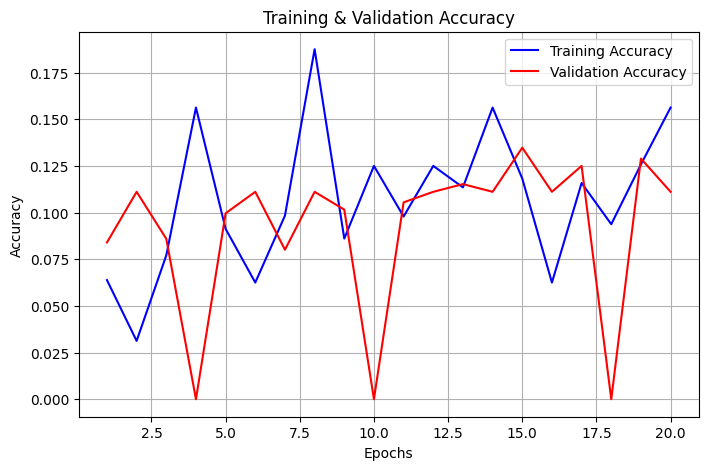

In [25]:
import matplotlib.pyplot as plt

# Extract accuracy values from history
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(train_acc) + 1)

# Plot Accuracy Graph
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.grid()
plt.show()


In [13]:
num_classes = len(train_generator.class_indices)
print(num_classes)

28


In [14]:
print(train_generator.num_classes)

28
